# RT-DETR Design Constraints

This notebook summarizes the separate RT-DETR constraints package generated in `constraints_rtdetr/`.

It reuses the saved `summary.json` and figure outputs instead of touching the main app or training code.

In [ ]:
from pathlib import Path
import json

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name != 'constraints_rtdetr':
    ROOT = ROOT / 'constraints_rtdetr'

SUMMARY_PATH = ROOT / 'summary.json'
FIGURES_DIR = ROOT / 'figures'
summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))
summary

{'dataset': {'train_images': 312,
  'val_images': 217,
  'total_images': 529,
  'train_instances': {'good': 186,
   'exc_solder': 182,
   'spike': 130,
   'poor_solder': 57},
  'val_instances': {'good': 125,
   'exc_solder': 133,
   'spike': 101,
   'poor_solder': 34},
  'total_instances': {'good': 311,
   'exc_solder': 315,
   'spike': 231,
   'poor_solder': 91},
  'smallest_class': 'poor_solder',
  'smallest_class_count': 91,
  'largest_class': 'exc_solder',
  'largest_class_count': 315,
  'imbalance_ratio': 3.4615384615384617,
  'input_resolution': '640 x 640',
  'classes': ['Good Solder',
   'Excess Solder',
   'Insufficient Solder',
   'Solder Spike']},
 'performance': {'precision': 0.9263780438404575,
  'recall': 0.9593864749751905,
  'map50': 0.9749574799277838,
  'map50_95': 0.8780956076242197,
  'weakest_class': 'spike',
  'weakest_class_map50_95': 0.80961,
  'class_map50_95': {'good': 0.93612,
   'exc_solder': 0.94187,
   'poor_solder': 0.82478,
   'spike': 0.80961}},
 'laten

## Quick Result Explanations

- `312 train / 217 val, 4 classes`: RT-DETR was trained on 312 labeled images and validated on 217 images across four solder classes.
- `97.50% mAP50 and 87.81% mAP50-95`: the current best checkpoint is strong overall, but strict localization quality remains lower than coarse detection quality.
- `418.45 ms CPU wall-clock latency`: this is usable for semi-automatic inspection, but not strict real-time CPU deployment.
- `69 epochs`: the run converged late, with best mAP50 at epoch 68 and best mAP50-95 at epoch 69.
- `high data dependency`: the smallest class, insufficient solder, has only 91 total labeled instances.

In [ ]:
dataset = summary['dataset']
performance = summary['performance']
training = summary['training']
latency = summary['latency']
dependency = summary['data_dependency']

dataset_table = pd.DataFrame([
    {'Metric': 'Total Labeled Images', 'Value': dataset['total_images']},
    {'Metric': 'Training Images', 'Value': dataset['train_images']},
    {'Metric': 'Validation Images', 'Value': dataset['val_images']},
    {'Metric': 'Input Resolution', 'Value': dataset['input_resolution']},
    {'Metric': 'Number of Classes', 'Value': len(dataset['classes'])},
    {'Metric': 'Smallest Class', 'Value': f"{dependency['smallest_class']} ({dependency['smallest_class_count']})"},
    {'Metric': 'Largest-to-Smallest Ratio', 'Value': f"{dependency['imbalance_ratio']:.2f}x"},
])
dataset_table

In [ ]:
performance_table = pd.DataFrame([
    {'Metric': 'Precision', 'Value': f"{performance['precision'] * 100:.2f}%"},
    {'Metric': 'Recall', 'Value': f"{performance['recall'] * 100:.2f}%"},
    {'Metric': 'mAP50', 'Value': f"{performance['map50'] * 100:.2f}%"},
    {'Metric': 'mAP50-95', 'Value': f"{performance['map50_95'] * 100:.2f}%"},
    {'Metric': 'Weakest Class', 'Value': f"{performance['weakest_class']} ({performance['weakest_class_map50_95'] * 100:.2f}%)"},
])
performance_table

In [ ]:
training_table = pd.DataFrame([
    {'Metric': 'Total Epochs', 'Value': training['total_epochs']},
    {'Metric': 'Final mAP50', 'Value': f"{training['final_map50'] * 100:.2f}%"},
    {'Metric': 'Final mAP50-95', 'Value': f"{training['final_map50_95'] * 100:.2f}%"},
    {'Metric': 'Best mAP50', 'Value': f"{training['best_map50'] * 100:.2f}% at epoch {training['best_map50_epoch']}"},
    {'Metric': 'Best mAP50-95', 'Value': f"{training['best_map50_95'] * 100:.2f}% at epoch {training['best_map50_95_epoch']}"},
    {'Metric': 'Training Time', 'Value': f"{training['training_time_seconds'] / 60:.2f} min"},
])
training_table

In [ ]:
latency_table = pd.DataFrame([
    {'Metric': 'Samples', 'Value': latency['samples']},
    {'Metric': 'Mean Preprocess Latency', 'Value': f"{latency['preprocess_mean_ms']:.2f} ms"},
    {'Metric': 'Mean Inference Latency', 'Value': f"{latency['inference_mean_ms']:.2f} ms"},
    {'Metric': 'Inference Std', 'Value': f"{latency['inference_std_ms']:.2f} ms"},
    {'Metric': 'Mean Postprocess Latency', 'Value': f"{latency['postprocess_mean_ms']:.2f} ms"},
    {'Metric': 'Mean Wall-Clock Latency', 'Value': f"{latency['wall_mean_ms']:.2f} ms"},
    {'Metric': 'Wall-Clock Std', 'Value': f"{latency['wall_std_ms']:.2f} ms"},
])
latency_table

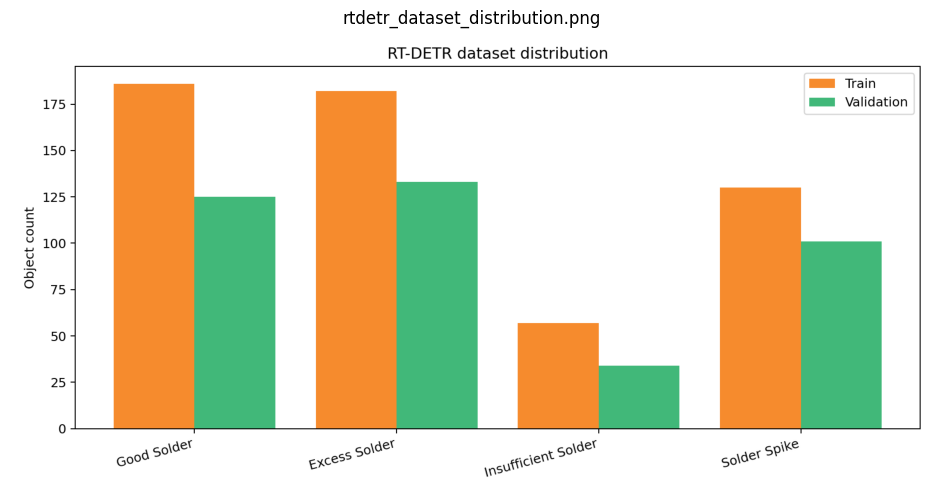

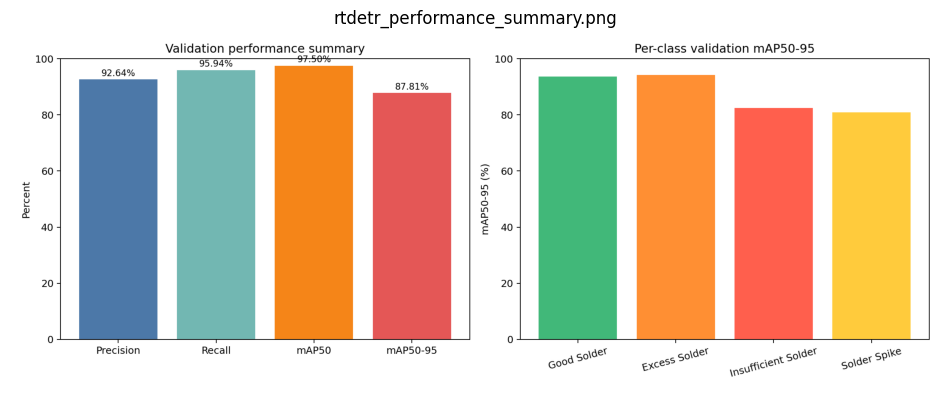

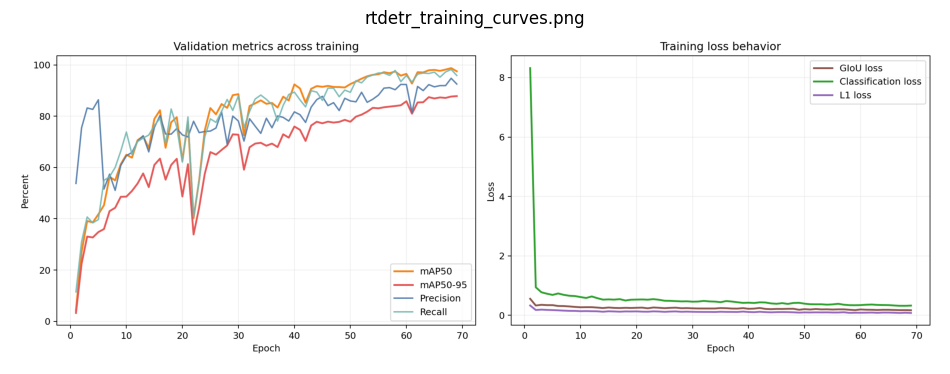

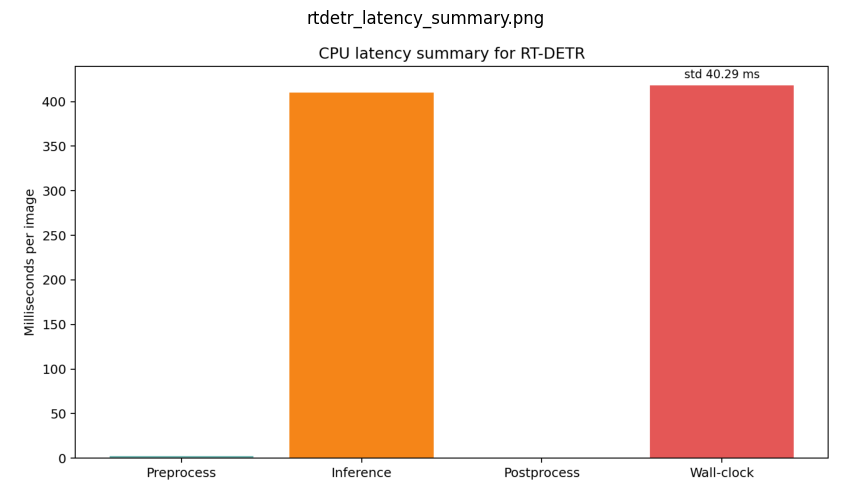

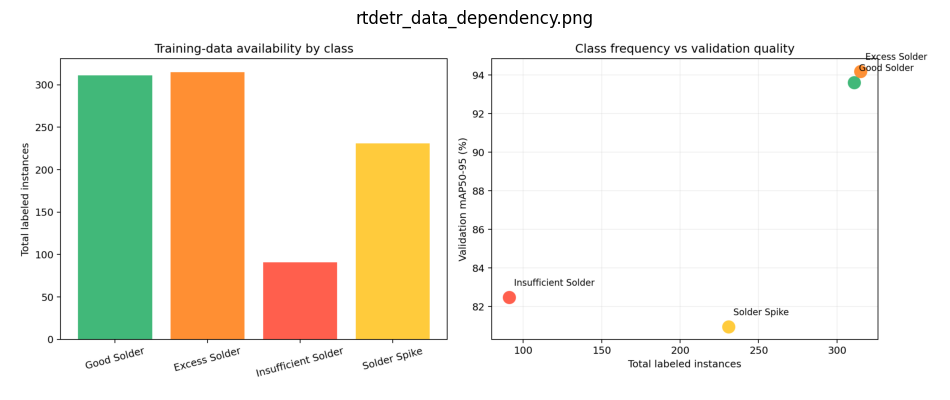

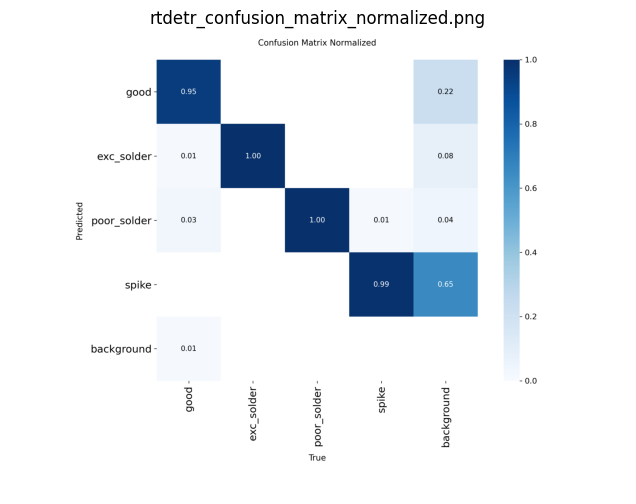

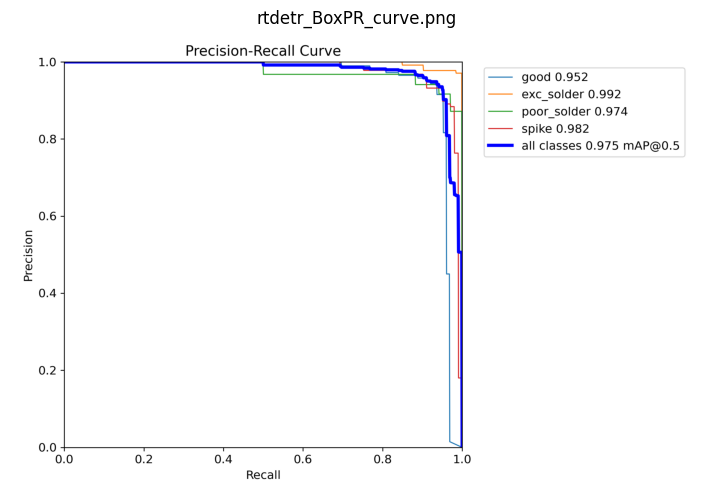

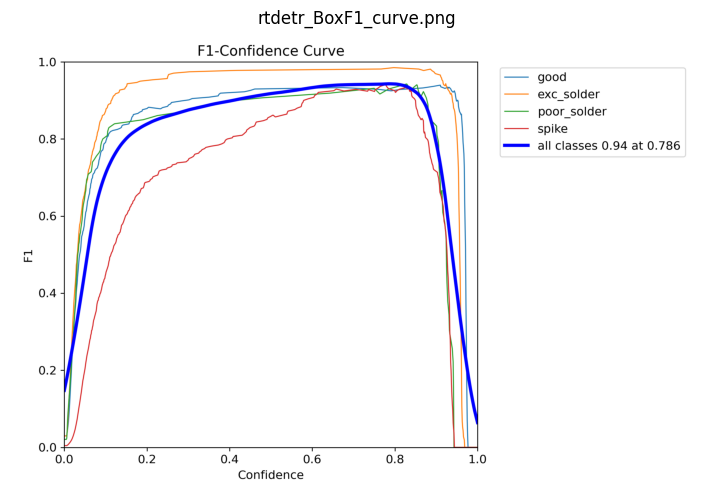

In [3]:
figure_files = [
    'rtdetr_dataset_distribution.png',
    'rtdetr_performance_summary.png',
    'rtdetr_training_curves.png',
    'rtdetr_latency_summary.png',
    'rtdetr_data_dependency.png',
    'rtdetr_confusion_matrix_normalized.png',
    'rtdetr_BoxPR_curve.png',
    'rtdetr_BoxF1_curve.png',
]

for figure_name in figure_files:
    figure_path = FIGURES_DIR / figure_name
    if not figure_path.exists():
        continue
    image = mpimg.imread(figure_path)
    plt.figure(figsize=(12, 6))
    plt.imshow(image)
    plt.title(figure_name)
    plt.axis('off')
    plt.show()

## Notes

- This notebook is separate from the main RT-DETR notebook and does not modify the app or training code.
- The values in this notebook come from `constraints_rtdetr/summary.json` and the saved figures in `constraints_rtdetr/figures`.
- If the model is retrained later, rerun `constraints_rtdetr/build_rtdetr_constraints.py` to refresh the figures and summary.

In [1]:
print("iv. Evaluation Results (if model)")
print()
print(f"{'Class':<15}{'Precision':>12}{'Recall':>10}{'F1-Score':>12}{'Support':>14}")
print("-" * 63)
print(f"{'background':<15}{0.999:>12.3f}{0.998:>10.3f}{0.998:>12.3f}{21467851:>14,}")
print(f"{'exc_solder':<15}{0.798:>12.3f}{0.877:>10.3f}{0.835:>12.3f}{158726:>14,}")
print(f"{'good':<15}{0.710:>12.3f}{0.811:>10.3f}{0.757:>12.3f}{394480:>14,}")
print(f"{'no_good':<15}{0.846:>12.3f}{0.749:>10.3f}{0.794:>12.3f}{424278:>14,}")
print(f"{'poor_solder':<15}{0.608:>12.3f}{0.670:>10.3f}{0.638:>12.3f}{35725:>14,}")
print(f"{'spike':<15}{0.807:>12.3f}{0.745:>10.3f}{0.775:>12.3f}{63324:>14,}")
print()
print(f"{'accuracy':<37}{0.988:>12.3f}{22544384:>14,}")
print(f"{'macro avg':<15}{0.795:>12.3f}{0.808:>10.3f}{0.800:>12.3f}{22544384:>14,}")
print(f"{'weighted avg':<15}{0.988:>12.3f}{0.988:>10.3f}{0.988:>12.3f}{22544384:>14,}")

iv. Evaluation Results (if model)

Class             Precision    Recall    F1-Score       Support
---------------------------------------------------------------
background            0.999     0.998       0.998    21,467,851
exc_solder            0.798     0.877       0.835       158,726
good                  0.710     0.811       0.757       394,480
no_good               0.846     0.749       0.794       424,278
poor_solder           0.608     0.670       0.638        35,725
spike                 0.807     0.745       0.775        63,324

accuracy                                    0.988    22,544,384
macro avg             0.795     0.808       0.800    22,544,384
weighted avg          0.988     0.988       0.988    22,544,384
